# 轮次

我们把遍历一次训练集称为"一轮"。在深度学习中，这个概念有一个正式术语：**轮次**（Epoch）。

无论采用哪种梯度下降方式，遍历一次完整训练集就是一个轮次。如果训练集有 $n$ 个样本：

* **随机梯度下降**（批大小 = 1）：每轮进行 $n$ 次迭代；
* **小批量梯度下降**（批大小 = $m$）：每轮进行 $n/m$ 次迭代；
* **全批量梯度下降**（批大小 = $n$）：每轮仅 1 次迭代。

实践中，网络模型需要**多个轮次**的训练，参数才能充分收敛。究竟需要多少轮，取决于数据量、模型复杂度和任务难度。

In [1]:
import matplotlib.pyplot as plt
import numpy as np

``💡 Matplotlib 是 Python 最常用的数据可视化库，用于绘制图表。本章用它绘制损失曲线，直观展示训练过程。``

## 数据集

与前两章相同的数据集，直接沿用。

### 训练数据：特征、标签

In [2]:
train_features = np.array([[22.5, 72.0],
                           [31.4, 45.0],
                           [19.8, 85.0],
                           [27.6, 63.0]])
train_labels = np.array([[95],
                         [210],
                         [70],
                         [155]])

### 测试数据：特征、标签

In [3]:
test_features = np.array([[28.1, 58.0]])
test_labels = np.array([[165]])

## 模型

与前两章相同，直接沿用。

### 参数：权重、偏置

In [4]:
weight = np.ones((1, 2)) / 2
bias = np.zeros(1)

### 推理函数

In [5]:
def forward(x, w, b):
    return x @ w.T + b

### 损失函数（均方误差）

In [6]:
def mse_loss(p, y):
    return np.mean(np.square(y - p))

### 梯度函数

In [7]:
def gradient(p, y):
    return -2 * (y - p) / len(y)

### 反向函数

In [8]:
def backward(x, d, w, b, lr):
    w -= d.T @ x * lr
    b -= np.sum(d, axis=0) * lr
    return w, b

## 训练

### 超参数：学习率

In [9]:
LEARNING_RATE = 0.00001

### 超参数：批大小

In [10]:
BATCH_SIZE = 2

### 超参数：轮数

**轮数**（Epochs）是本章引入的第三个超参数，定义了训练集被完整遍历的次数。

轮数并非越多越好：

* **太少**：参数还没收敛，模型欠拟合；
* **太多**：在复杂模型中，可能出现**过拟合**。模型在训练集上越来越好，但在测试集上性能停滞甚至变差。

确定合适轮数的常用方法是**监测损失曲线**：当测试集损失不再明显下降时，继续训练的收益就很小了。

实践中常用的辅助技巧是**早停**（Early Stopping）：在每轮结束后检查测试集损失，如果连续若干轮（通常 10～20 轮）都没有改善，就提前停止训练，防止过拟合和浪费计算资源。

``💡 早停应该监测测试集损失，而不是训练集损失。训练集损失几乎总会随轮数增加而下降，但测试集损失才反映模型的真实泛化能力。``

In [11]:
EPOCHS = 1000

### 迭代

用一个嵌套循环实现多轮训练：外层循环遍历轮次，内层循环遍历每个批次。

实践中还有一个常用技巧：在每轮开始前随机打乱训练数据的顺序，称为**重排**（Shuffle）。打乱顺序可以避免模型每轮都按同样的批次顺序学习，在数据量较大时有助于改善收敛稳定性。

In [12]:
for epoch in range(EPOCHS):
    for i in range(0, len(train_features), BATCH_SIZE):
        features = train_features[i: i + BATCH_SIZE]
        labels = train_labels[i: i + BATCH_SIZE]

        predictions = forward(features, weight, bias)
        delta = gradient(predictions, labels)
        weight, bias = backward(features, delta, weight, bias, LEARNING_RATE)

print(f'weight: {weight}')
print(f'bias:   {bias}')

weight: [[ 8.04709172 -1.08194575]]
bias:   [0.15285452]


## 验证

### 推理

In [13]:
predictions = forward(test_features, weight, bias)
print(f'predictions: {predictions}')

predictions: [[163.52327795]]


### 评估

In [14]:
loss = mse_loss(predictions, test_labels)
print(f'loss: {loss:.4f}')

loss: 2.1807


经过 1000 轮训练，损失值从最初的 ``14,871`` 降至 ``2.18``，下降了 99.98%。

预测值 ``163.5`` 与真实值 ``165`` 相差 1 个冰激凌，模型训练成功！

注意权重的变化：温度权重约为 ``8.05``，湿度权重约为 ``-1.08``。模型从数据中自主学到了：温度对销量的影响是正面且强烈的，而湿度的影响则是轻微的负面。这符合我们对冰激凌销量的直觉。

### 损失曲线

光看最终数字不够直观。下面从头记录每轮的损失值，绘制**损失曲线**（Loss Curve），观察整个训练过程。

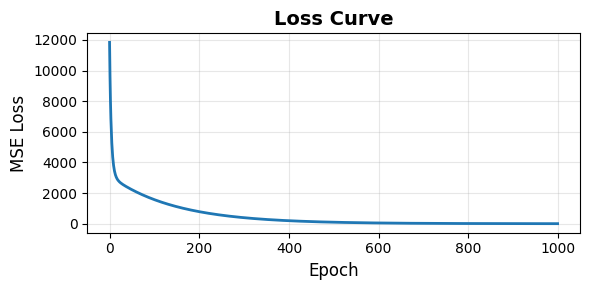

In [15]:
# 重新初始化参数，完整记录 1000 轮的损失历史
weight = np.ones((1, 2)) / 2
bias = np.zeros(1)
losses = []

for epoch in range(EPOCHS):
    # 训练
    for i in range(0, len(train_features), BATCH_SIZE):
        features = train_features[i: i + BATCH_SIZE]
        labels = train_labels[i: i + BATCH_SIZE]
        predictions = forward(features, weight, bias)
        delta = gradient(predictions, labels)
        weight, bias = backward(features, delta, weight, bias, LEARNING_RATE)

    # 每轮结束后在测试集上评估
    predictions = forward(test_features, weight, bias)
    losses.append(mse_loss(predictions, test_labels))

# 绘制损失曲线
plt.figure(figsize=(6, 3))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Loss Curve', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

损失曲线清晰地展示了训练过程的三个阶段：

* **快速下降期**（前 100 轮）：损失值从 11839 骤降至约 1580，下降了约 87%。参数离初始值较远，每步改进幅度最大；
* **稳定收敛期**（100 ～ 500 轮）：损失值从 1580 继续降至约 96，改进仍然显著，但速度趋于平稳；
* **精细调整期**（500 ～ 1000 轮）：损失值从 96 降至 2.18，幅度不大，但对最终精度至关重要。

这条曲线没有明显的"拐点"，损失一直在稳定下降，没有出现先降后升的过拟合迹象。这是因为我们的模型结构简单（单层线性回归），不容易过拟合。在后续章节引入更复杂的多层网络后，才更容易观察到过拟合带来的拐点。

## 课后练习

在训练循环中加入早停逻辑。如果连续 50 轮，测试集损失没有改善（即当前损失 ≥ 历史最低损失），就提前停止训练。早停的最终损失与跑满 1000 轮相比如何？